In [2]:
sales = pd.read_csv("/content/sales_data.csv")
customers = pd.read_csv("/content/customer_data.csv")

print(sales.columns.tolist())
print(customers.columns.tolist())

['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']
['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn']


CUSTOMER SALES ANALYSIS PROJECT

Datasets Loaded Successfully

Sales Shape: (100, 7)
Customer Shape: (500, 9)

Sales Columns
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

Customer Columns
Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

Missing Values in Sales
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Missing Values in Customers
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Data Cleaning Completed

Merged Dataset Shape: (100, 16)

SUMMARY METRICS
----------------------------------------
Total Revenue: 12365048
Average Order Value: 123650.48
To

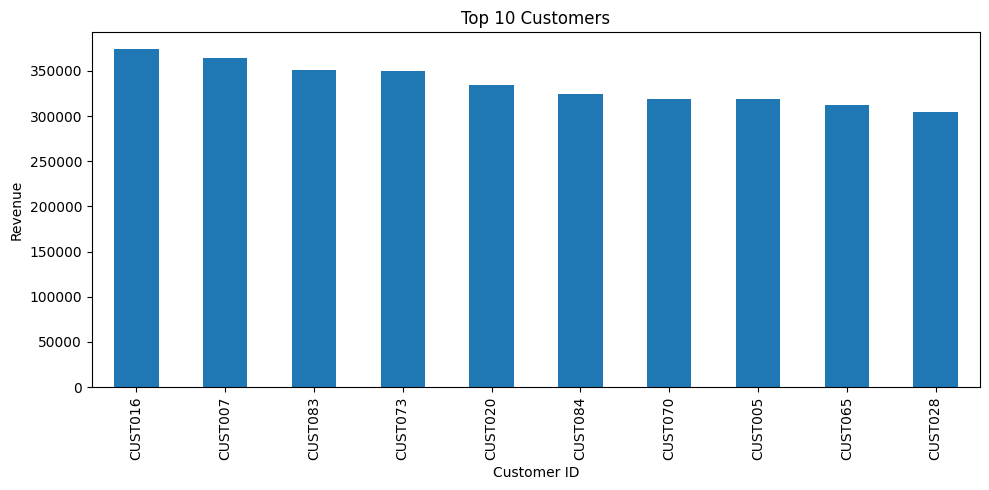

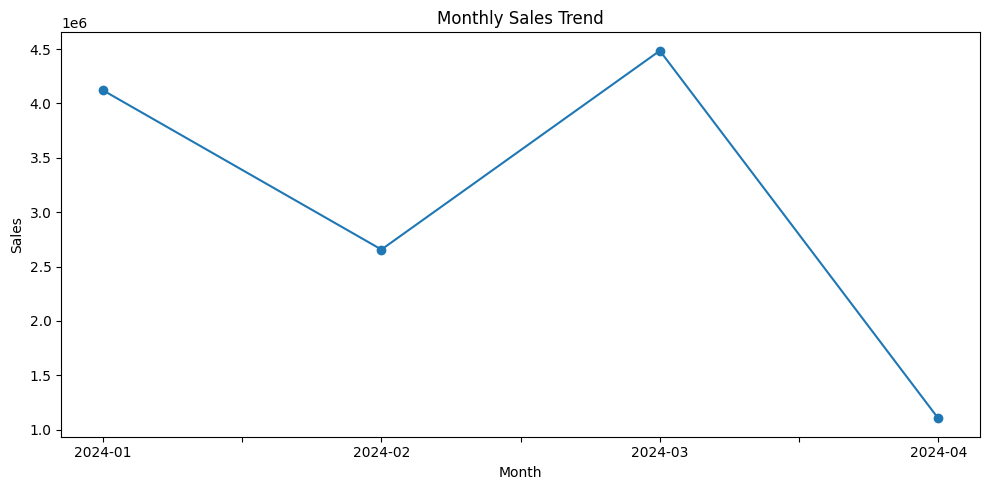

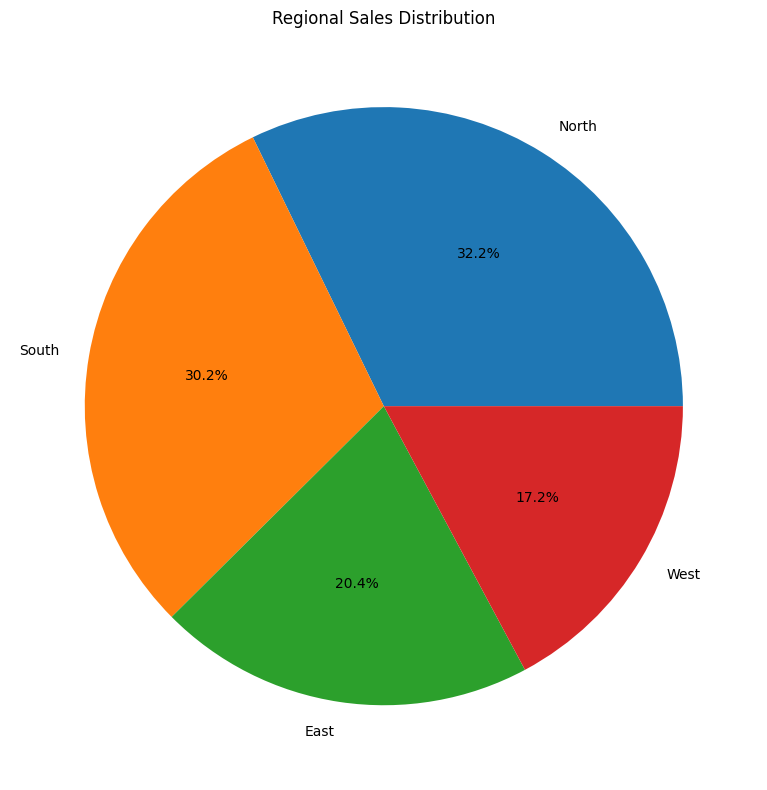

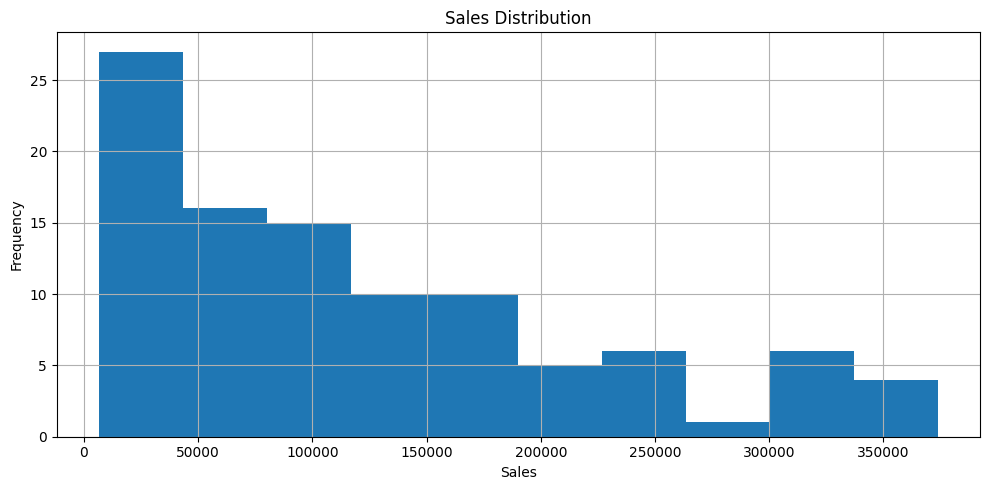



BUSINESS INSIGHTS

Top Customer: CUST016
Revenue Generated: 373932

Best Selling Product:
Laptop

Highest Sales Region:
North

Recommendations
1. Reward high-value customers.
2. Focus marketing in North region.
3. Promote laptops aggressively.
4. Monitor monthly sales trends.
5. Use customer segmentation for future campaigns.

PROJECT COMPLETED SUCCESSFULLY


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

print("="*60)
print("CUSTOMER SALES ANALYSIS PROJECT")
print("="*60)


sales = pd.read_csv("/content/sales_data.csv")
customers = pd.read_csv("/content/customer_data.csv")

print("\nDatasets Loaded Successfully")


print("\nSales Shape:", sales.shape)
print("Customer Shape:", customers.shape)

print("\nSales Columns")
print(sales.columns)

print("\nCustomer Columns")
print(customers.columns)

print("\nMissing Values in Sales")
print(sales.isnull().sum())

print("\nMissing Values in Customers")
print(customers.isnull().sum())


sales.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)

sales.fillna(0, inplace=True)
customers.fillna("Unknown", inplace=True)

print("\nData Cleaning Completed")


merged_data = pd.merge(
    sales,
    customers,
    left_on="Customer_ID",
    right_on="CustomerID",
    how="left"
)

print("\nMerged Dataset Shape:", merged_data.shape)


total_revenue = merged_data["Total_Sales"].sum()
average_order_value = merged_data["Total_Sales"].mean()
total_customers = merged_data["Customer_ID"].nunique()
total_transactions = len(merged_data)

print("\nSUMMARY METRICS")
print("-"*40)

print("Total Revenue:", round(total_revenue,2))
print("Average Order Value:", round(average_order_value,2))
print("Total Customers:", total_customers)
print("Total Transactions:", total_transactions)


customer_sales = (
    merged_data.groupby("Customer_ID")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTOP 10 CUSTOMERS")
print(customer_sales.head(10))

top_customer = customer_sales.idxmax()
top_customer_sales = customer_sales.max()

product_sales = (
    merged_data.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nPRODUCT SALES")
print(product_sales)


regional_sales = (
    merged_data.groupby("Region")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nREGIONAL SALES")
print(regional_sales)


merged_data["Date"] = pd.to_datetime(merged_data["Date"])

merged_data["Month"] = merged_data["Date"].dt.strftime("%Y-%m")

monthly_sales = (
    merged_data.groupby("Month")["Total_Sales"]
    .sum()
)

print("\nMONTHLY SALES")
print(monthly_sales)


pivot_table = pd.pivot_table(
    merged_data,
    values="Total_Sales",
    index="Region",
    columns="Product",
    aggfunc="sum",
    fill_value=0
)

print("\nPIVOT TABLE")
print(pivot_table)


plt.figure(figsize=(10,5))

customer_sales.head(10).plot(kind="bar")

plt.title("Top 10 Customers")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,8))

regional_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Regional Sales Distribution")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))

merged_data["Total_Sales"].hist(
    bins=10
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


if "Churn" in merged_data.columns:

    churn_data = merged_data.dropna(subset=["Churn"])

    if len(churn_data) > 0:

        churn_analysis = (
            churn_data.groupby("Churn")["Total_Sales"]
            .sum()
        )

        plt.figure(figsize=(6,4))

        churn_analysis.plot(kind="bar")

        plt.title("Sales by Churn Status")
        plt.xlabel("Churn")
        plt.ylabel("Sales")

        plt.tight_layout()
        plt.show()


print("\n")
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print(f"\nTop Customer: {top_customer}")
print(f"Revenue Generated: {round(top_customer_sales,2)}")

print("\nBest Selling Product:")
print(product_sales.idxmax())

print("\nHighest Sales Region:")
print(regional_sales.idxmax())

print("\nRecommendations")

print("1. Reward high-value customers.")
print("2. Focus marketing in North region.")
print("3. Promote laptops aggressively.")
print("4. Monitor monthly sales trends.")
print("5. Use customer segmentation for future campaigns.")

print("\nPROJECT COMPLETED SUCCESSFULLY")